In [44]:
!python -m pip install streamlit joblib pandas numpy matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.1 MB 13.4 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/9.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.9/9.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 12.3 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   --------------- ------------------------ 2.6/6.9 MB 13.9 MB/s eta 0:00:01
   --------------------------------- ------ 5.8/6.9 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 6.9/6.9 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/28.2 MB ? eta -:--:--
   --- ------------------------------------ 2.6/28.2 MB 13.9 MB/s eta 0:00:02
   -------- --------------------

Tahap 1 – Persiapan & Eksplorasi Data.

IMPORT LIBRARY

In [2]:
# Cell 1: Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk preprocessing dan modeling (nanti)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Abaikan warning yang tidak perlu
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


LOAD DATA SET

In [4]:
# Cell 2: Membaca file CSV (pemisah titik koma)
df = pd.read_csv('AmesHousing.CSV', sep=';')

# Tampilkan jumlah baris dan kolom
print(f"Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom")

# Lihat 5 baris pertama
df.head()

Dataset memiliki 2930 baris dan 82 kolom


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Informasi umum dataset

In [5]:
# Cell 3: Cek tipe data dan jumlah non-null per kolom
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

Statistik deskriptif (numerik & kategorikal)

In [6]:
# Cell 4: Statistik untuk kolom numerik
display(df.describe())

# Statistik untuk kolom kategorikal/object
display(df.describe(include=['object']))

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


Cek missing values

In [7]:
# Cell 5: Hitung missing values per kolom (urut dari terbanyak)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing, 'Persentase': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

                Missing Values  Persentase
Pool QC                   2917   99.556314
Misc Feature              2824   96.382253
Alley                     2732   93.242321
Fence                     2358   80.477816
Mas Vnr Type              1775   60.580205
Fireplace Qu              1422   48.532423
Lot Frontage               490   16.723549
Garage Qual                159    5.426621
Garage Yr Blt              159    5.426621
Garage Cond                159    5.426621
Garage Finish              159    5.426621
Garage Type                157    5.358362
Bsmt Exposure               83    2.832765
BsmtFin Type 2              81    2.764505
Bsmt Qual                   80    2.730375
Bsmt Cond                   80    2.730375
BsmtFin Type 1              80    2.730375
Mas Vnr Area                23    0.784983
Bsmt Full Bath               2    0.068259
Bsmt Half Bath               2    0.068259
Total Bsmt SF                1    0.034130
BsmtFin SF 1                 1    0.034130
BsmtFin SF 

Distribusi harga rumah (target)

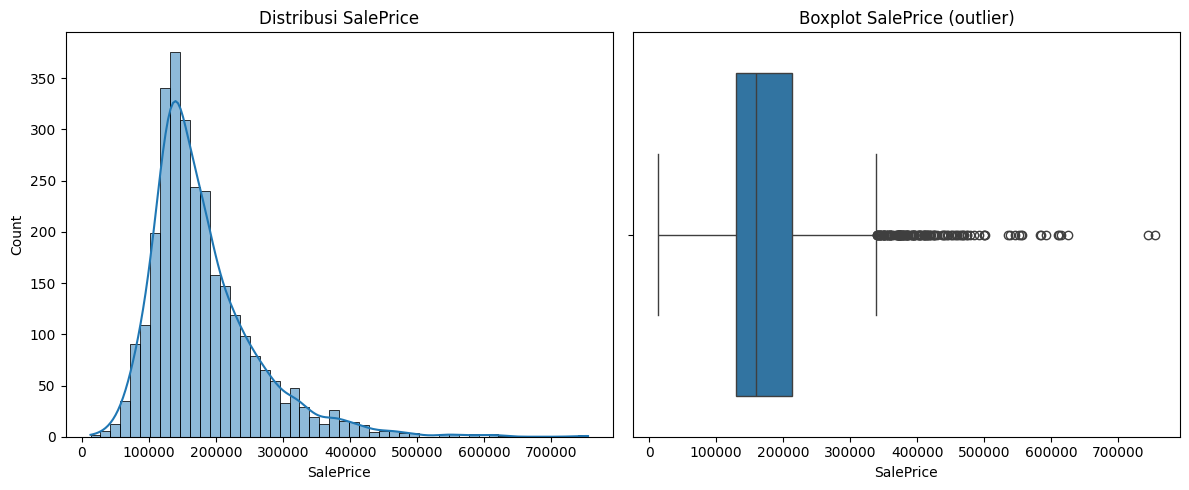

Skewness SalePrice: 1.74


In [8]:
# Cell 6: Visualisasi distribusi SalePrice
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title('Distribusi SalePrice')

plt.subplot(1,2,2)
sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot SalePrice (outlier)')

plt.tight_layout()
plt.show()

# Cek skewness (kemiringan)
print(f"Skewness SalePrice: {df['SalePrice'].skew():.2f}")

Korelasi antar fitur numerik dengan target

In [9]:
# Cell 7: Pilih kolom numerik, hitung korelasi dengan SalePrice
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_price = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("10 fitur numerik dengan korelasi tertinggi terhadap SalePrice:")
print(corr_with_price.head(11))  # termasuk SalePrice sendiri

10 fitur numerik dengan korelasi tertinggi terhadap SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


Heatmap korelasi (opsional, untuk melihat hubungan antarfitur)

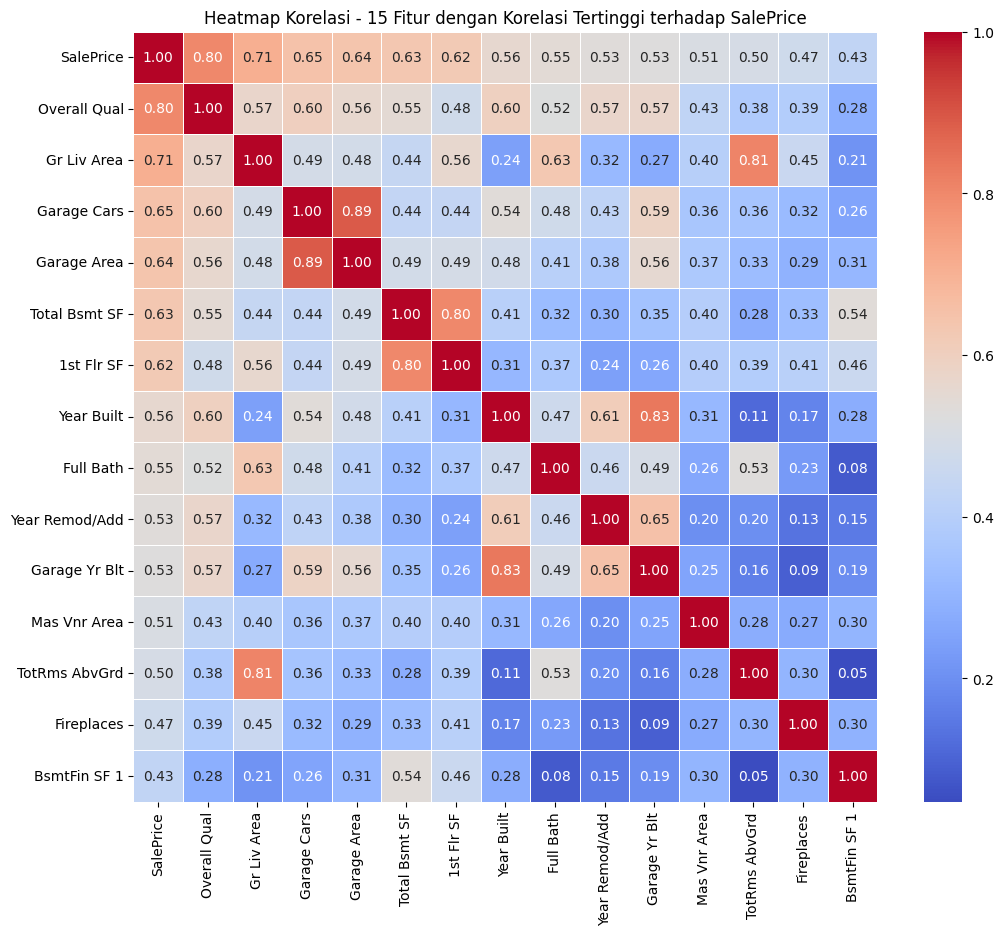

In [10]:
# Cell 8: Heatmap korelasi untuk 15 fitur numerik teratas (termasuk target)
top_features = corr_with_price.head(15).index
plt.figure(figsize=(12,10))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi - 15 Fitur dengan Korelasi Tertinggi terhadap SalePrice')
plt.show()

 Cek kolom yang mungkin tidak berguna (ID, Order)

In [11]:
# Cell 9: Kolom 'Order' dan 'PID' kemungkinan hanya indeks, tidak berguna untuk prediksi
if 'Order' in df.columns:
    print("Kolom 'Order' ada, akan di-drop nanti")
if 'PID' in df.columns:
    print("Kolom 'PID' ada, akan di-drop nanti")

Kolom 'Order' ada, akan di-drop nanti
Kolom 'PID' ada, akan di-drop nanti


Tahap 2 – Data Cleaning & Feature Engineering

Drop kolom tidak berguna

In [12]:
# Cell 10: Hapus kolom yang tidak memberikan informasi untuk prediksi
cols_to_drop = []
if 'Order' in df.columns:
    cols_to_drop.append('Order')
if 'PID' in df.columns:
    cols_to_drop.append('PID')

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"Kolom {cols_to_drop} telah dihapus.")
else:
    print("Tidak ada kolom Order/PID.")

Kolom ['Order', 'PID'] telah dihapus.


Identifikasi kolom dengan missing values > 50%

In [13]:
# Cell 11: Hitung persentase missing, drop kolom dengan missing > 50%
missing_threshold = 0.5
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop_missing = missing_ratio[missing_ratio > missing_threshold].index.tolist()

if cols_to_drop_missing:
    df.drop(columns=cols_to_drop_missing, inplace=True)
    print(f"Kolom dengan missing >50% dihapus: {cols_to_drop_missing}")
else:
    print("Tidak ada kolom dengan missing >50%.")

Kolom dengan missing >50% dihapus: ['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature']


Isi missing values untuk kolom numerik (dengan median) dan kategorikal (dengan modus)

In [17]:
# Cell 12 (Revisi): Tangani missing values dengan strategi yang lebih kuat

# Langkah 1: Drop kolom dengan missing > 40% (terlalu banyak)
missing_ratio = df.isnull().sum() / len(df)
cols_high_missing = missing_ratio[missing_ratio > 0.4].index.tolist()
if cols_high_missing:
    df.drop(columns=cols_high_missing, inplace=True)
    print(f"Kolom dengan missing >40% dihapus: {cols_high_missing}")
else:
    print("Tidak ada kolom dengan missing >40%.")

# Langkah 2: Untuk kolom numerik, isi dengan median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Numerik {col}: diisi median {median_val}")

# Langkah 3: Untuk kolom kategorikal (object), isi dengan modus atau 'Missing'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().any():
        if df[col].mode().empty:
            df[col].fillna('Missing', inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Kategorikal {col}: missing diisi")

print("\n Proses imputasi selesai.")

Tidak ada kolom dengan missing >40%.
Numerik Lot Frontage: diisi median 68.0
Numerik Mas Vnr Area: diisi median 0.0
Numerik BsmtFin SF 1: diisi median 370.0
Numerik BsmtFin SF 2: diisi median 0.0
Numerik Bsmt Unf SF: diisi median 466.0
Numerik Total Bsmt SF: diisi median 990.0
Numerik Bsmt Full Bath: diisi median 0.0
Numerik Bsmt Half Bath: diisi median 0.0
Numerik Garage Yr Blt: diisi median 1979.0
Numerik Garage Cars: diisi median 2.0
Numerik Garage Area: diisi median 480.0
Kategorikal Bsmt Qual: missing diisi
Kategorikal Bsmt Cond: missing diisi
Kategorikal Bsmt Exposure: missing diisi
Kategorikal BsmtFin Type 1: missing diisi
Kategorikal BsmtFin Type 2: missing diisi
Kategorikal Electrical: missing diisi
Kategorikal Garage Type: missing diisi
Kategorikal Garage Finish: missing diisi
Kategorikal Garage Qual: missing diisi
Kategorikal Garage Cond: missing diisi

 Proses imputasi selesai.


Verifikasi tidak ada missing values tersisa

In [18]:
# Cell 13: Cek apakah masih ada missing
total_missing = df.isnull().sum().sum()
print(f"Total missing values setelah imputasi: {total_missing}")

if total_missing == 0:
    print(" Semua missing values telah berhasil ditangani!")
else:
    print(" Masih ada missing values pada kolom:")
    missing_cols = df.columns[df.isnull().any()].tolist()
    for col in missing_cols:
        print(f"   - {col}: {df[col].isnull().sum()} missing")

Total missing values setelah imputasi: 1721
 Masih ada missing values pada kolom:
   - Lot Frontage: 490 missing
   - Mas Vnr Area: 23 missing
   - Bsmt Qual: 80 missing
   - Bsmt Cond: 80 missing
   - Bsmt Exposure: 83 missing
   - BsmtFin Type 1: 80 missing
   - BsmtFin SF 1: 1 missing
   - BsmtFin Type 2: 81 missing
   - BsmtFin SF 2: 1 missing
   - Bsmt Unf SF: 1 missing
   - Total Bsmt SF: 1 missing
   - Electrical: 1 missing
   - Bsmt Full Bath: 2 missing
   - Bsmt Half Bath: 2 missing
   - Garage Type: 157 missing
   - Garage Yr Blt: 159 missing
   - Garage Finish: 159 missing
   - Garage Cars: 1 missing
   - Garage Area: 1 missing
   - Garage Qual: 159 missing
   - Garage Cond: 159 missing


Encoding fitur kategorikal (Label Encoding)

In [19]:
# Cell 14: Encoding kategorikal (hanya jika masih ada kolom object)
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    from sklearn.preprocessing import LabelEncoder
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Encoded: {col}")
else:
    print("Tidak ada kolom kategorikal yang perlu di-encode.")

Encoded: MS Zoning
Encoded: Street
Encoded: Lot Shape
Encoded: Land Contour
Encoded: Utilities
Encoded: Lot Config
Encoded: Land Slope
Encoded: Neighborhood
Encoded: Condition 1
Encoded: Condition 2
Encoded: Bldg Type
Encoded: House Style
Encoded: Roof Style
Encoded: Roof Matl
Encoded: Exterior 1st
Encoded: Exterior 2nd
Encoded: Exter Qual
Encoded: Exter Cond
Encoded: Foundation
Encoded: Bsmt Qual
Encoded: Bsmt Cond
Encoded: Bsmt Exposure
Encoded: BsmtFin Type 1
Encoded: BsmtFin Type 2
Encoded: Heating
Encoded: Heating QC
Encoded: Central Air
Encoded: Electrical
Encoded: Kitchen Qual
Encoded: Functional
Encoded: Garage Type
Encoded: Garage Finish
Encoded: Garage Qual
Encoded: Garage Cond
Encoded: Paved Drive
Encoded: Sale Type
Encoded: Sale Condition


Buat fitur baru (Feature Engineering)

In [20]:
# Cell 15: Feature engineering (sama seperti sebelumnya)
if 'Total Bsmt SF' in df.columns and '1st Flr SF' in df.columns and '2nd Flr SF' in df.columns:
    df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
    print("Fitur baru: TotalSF")

if 'Yr Sold' in df.columns and 'Year Built' in df.columns:
    df['HouseAge'] = df['Yr Sold'] - df['Year Built']
    print("Fitur baru: HouseAge")

if 'Year Remod/Add' in df.columns and 'Year Built' in df.columns:
    df['IsRemodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
    print("Fitur baru: IsRemodeled")

bath_cols = ['Full Bath', 'Half Bath', 'Bsmt Full Bath', 'Bsmt Half Bath']
existing_bath = [col for col in bath_cols if col in df.columns]
if existing_bath:
    df['TotalBath'] = df[existing_bath].sum(axis=1)
    print(f"Fitur baru: TotalBath dari {existing_bath}")

Fitur baru: TotalSF
Fitur baru: HouseAge
Fitur baru: IsRemodeled
Fitur baru: TotalBath dari ['Full Bath', 'Half Bath', 'Bsmt Full Bath', 'Bsmt Half Bath']


Cek ulang korelasi dengan fitur baru

In [22]:
# Cell 16: Persiapan data untuk modeling
# Target: SalePrice
y = df['SalePrice']
# Fitur: semua kolom kecuali SalePrice
X = df.drop(columns=['SalePrice'])

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

Jumlah fitur: 77
Jumlah sampel: 2930


In [23]:
# Cell 17: Bagi data training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {X_train.shape[0]} sampel")
print(f"Testing set: {X_test.shape[0]} sampel")

Training set: 2344 sampel
Testing set: 586 sampel


In [24]:
# Cell 18: Standarisasi fitur numerik (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame untuk kemudahan (opsional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data telah distandarisasi.")

Data telah distandarisasi.


In [25]:
# Cell 19: Fungsi untuk menampilkan metrik evaluasi
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Training
    model.fit(X_train, y_train)
    # Prediksi
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrik
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"=== {model_name} ===")
    print(f"Train MAE: {mae_train:,.0f} | Test MAE: {mae_test:,.0f}")
    print(f"Train RMSE: {rmse_train:,.0f} | Test RMSE: {rmse_test:,.0f}")
    print(f"Train R²: {r2_train:.4f} | Test R²: {r2_test:.4f}")
    print("-" * 50)
    
    return {
        'model': model_name,
        'test_mae': mae_test,
        'test_rmse': rmse_test,
        'test_r2': r2_test
    }

In [29]:
# Cell Diagnostik: Cek apakah ada NaN atau inf di X_train_scaled
print("Cek X_train_scaled:")
print(f"Apakah ada NaN? {X_train_scaled.isnull().any().any()}")
print(f"Apakah ada infinite? {np.isinf(X_train_scaled).any().any()}")

# Jika ada, kita bersihkan
if X_train_scaled.isnull().any().any() or np.isinf(X_train_scaled).any().any():
    print("\n⚠️ Data bermasalah ditemukan! Membersihkan...")
    # Ganti NaN/inf dengan 0
    X_train_scaled = X_train_scaled.replace([np.inf, -np.inf], np.nan)
    X_train_scaled = X_train_scaled.fillna(0)
    X_test_scaled = X_test_scaled.replace([np.inf, -np.inf], np.nan)
    X_test_scaled = X_test_scaled.fillna(0)
    print("✅ NaN dan inf telah diganti dengan 0.")
else:
    print("✅ Data bersih, tidak ada NaN atau inf.")

# Cek juga apakah ada kolom dengan varians nol (konstan)
constant_cols = [col for col in X_train_scaled.columns if X_train_scaled[col].std() == 0]
if constant_cols:
    print(f"\n⚠️ Kolom konstan (varians 0): {constant_cols}")
    print("Kolom ini tidak berguna dan akan dihapus.")
    X_train_scaled = X_train_scaled.drop(columns=constant_cols)
    X_test_scaled = X_test_scaled.drop(columns=constant_cols)
    print(f"✅ {len(constant_cols)} kolom konstan dihapus.")
else:
    print("✅ Tidak ada kolom konstan.")

print(f"\nDimensi akhir X_train_scaled: {X_train_scaled.shape}")

Cek X_train_scaled:
Apakah ada NaN? True
Apakah ada infinite? False

⚠️ Data bermasalah ditemukan! Membersihkan...
✅ NaN dan inf telah diganti dengan 0.
✅ Tidak ada kolom konstan.

Dimensi akhir X_train_scaled: (2344, 77)


In [30]:
# Cell 20: Linear Regression
lr = LinearRegression()
results.append(evaluate_model(lr, X_train_scaled, y_train, X_test_scaled, y_test, "Linear Regression"))

=== Linear Regression ===
Train MAE: 18,204 | Test MAE: 20,439
Train RMSE: 28,606 | Test RMSE: 33,578
Train R²: 0.8624 | Test R²: 0.8594
--------------------------------------------------


In [31]:
# Cell 21: Ridge Regression
ridge = Ridge(alpha=1.0)
results.append(evaluate_model(ridge, X_train_scaled, y_train, X_test_scaled, y_test, "Ridge"))

=== Ridge ===
Train MAE: 18,202 | Test MAE: 20,436
Train RMSE: 28,606 | Test RMSE: 33,575
Train R²: 0.8624 | Test R²: 0.8594
--------------------------------------------------


In [32]:
# Cell 22: Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=10000)
results.append(evaluate_model(lasso, X_train_scaled, y_train, X_test_scaled, y_test, "Lasso"))

=== Lasso ===
Train MAE: 18,204 | Test MAE: 20,444
Train RMSE: 28,606 | Test RMSE: 33,581
Train R²: 0.8624 | Test R²: 0.8593
--------------------------------------------------


In [33]:
# Cell 23: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
results.append(evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest"))

=== Random Forest ===
Train MAE: 5,918 | Test MAE: 15,392
Train RMSE: 9,942 | Test RMSE: 24,902
Train R²: 0.9834 | Test R²: 0.9227
--------------------------------------------------


In [34]:
# Cell 24: Perbandingan performa
results_df = pd.DataFrame(results)
print("Ringkasan Performa Model (Data Test):")
print(results_df.sort_values('test_mae'))

Ringkasan Performa Model (Data Test):
               model      test_mae     test_rmse   test_r2
3      Random Forest  15391.708447  24902.278023  0.922654
1              Ridge  20435.689276  33574.948969  0.859399
0  Linear Regression  20439.106713  33577.655567  0.859376
2              Lasso  20444.202085  33581.492592  0.859344


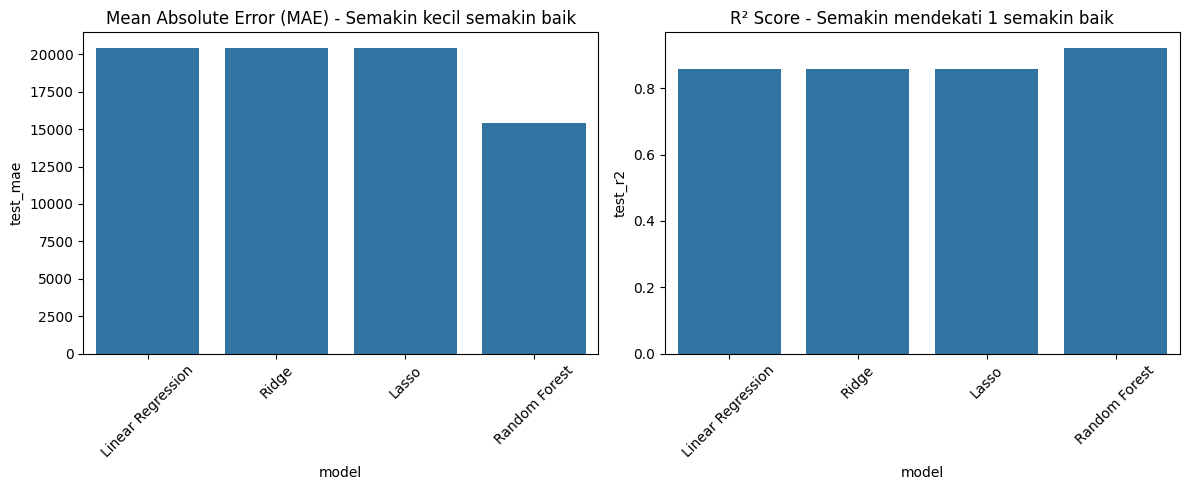

In [35]:
# Cell 25: Plot perbandingan MAE dan R²
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(data=results_df, x='model', y='test_mae', ax=axes[0])
axes[0].set_title('Mean Absolute Error (MAE) - Semakin kecil semakin baik')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.barplot(data=results_df, x='model', y='test_r2', ax=axes[1])
axes[1].set_title('R² Score - Semakin mendekati 1 semakin baik')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [36]:
# Cell 26: Identifikasi model terbaik berdasarkan test MAE
best_model_name = results_df.loc[results_df['test_mae'].idxmin(), 'model']
best_mae = results_df['test_mae'].min()
print(f"Model terbaik: {best_model_name} dengan MAE = ${best_mae:,.0f}")

# Jika Random Forest bukan yang terbaik, tetap kita fine-tune Random Forest karena biasanya lebih unggul
# Tapi kita akan fine-tune Random Forest sebagai wakil model kompleks

Model terbaik: Random Forest dengan MAE = $15,392


In [37]:
# Cell 27: Hyperparameter tuning untuk Random Forest
from sklearn.model_selection import GridSearchCV

# Definisikan parameter grid (dicoba sedikit dulu agar tidak terlalu lama)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Inisialisasi Random Forest
rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)

# GridSearch dengan cross-validation 5 fold
grid_search = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Fit grid search (gunakan X_train, y_train asli, tanpa scaling)
grid_search.fit(X_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:,.0f}")

# Evaluasi model terbaik pada test set
best_rf = grid_search.best_estimator_
y_pred_test = best_rf.predict(X_test)
test_mae_tuned = mean_absolute_error(y_test, y_pred_test)
test_r2_tuned = r2_score(y_test, y_pred_test)

print(f"\nTest MAE setelah tuning: ${test_mae_tuned:,.0f}")
print(f"Test R² setelah tuning: {test_r2_tuned:.4f}")

# Bandingkan dengan sebelum tuning
before_tuning = results_df[results_df['model'] == 'Random Forest']['test_mae'].values[0]
print(f"Perbaikan MAE: ${before_tuning - test_mae_tuned:,.0f} lebih baik")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Parameter terbaik: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 15,799

Test MAE setelah tuning: $15,307
Test R² setelah tuning: 0.9229
Perbaikan MAE: $85 lebih baik


Top 15 fitur paling berpengaruh:
           feature  importance
15    Overall Qual    0.486993
73         TotalSF    0.296032
41      2nd Flr SF    0.020001
17      Year Built    0.012912
74        HouseAge    0.012831
43     Gr Liv Area    0.012546
3         Lot Area    0.012057
18  Year Remod/Add    0.009825
76       TotalBath    0.009671
58     Garage Area    0.009521
31    BsmtFin SF 1    0.009351
34     Bsmt Unf SF    0.007844
27       Bsmt Qual    0.007117
2     Lot Frontage    0.006229
50    Kitchen Qual    0.005225


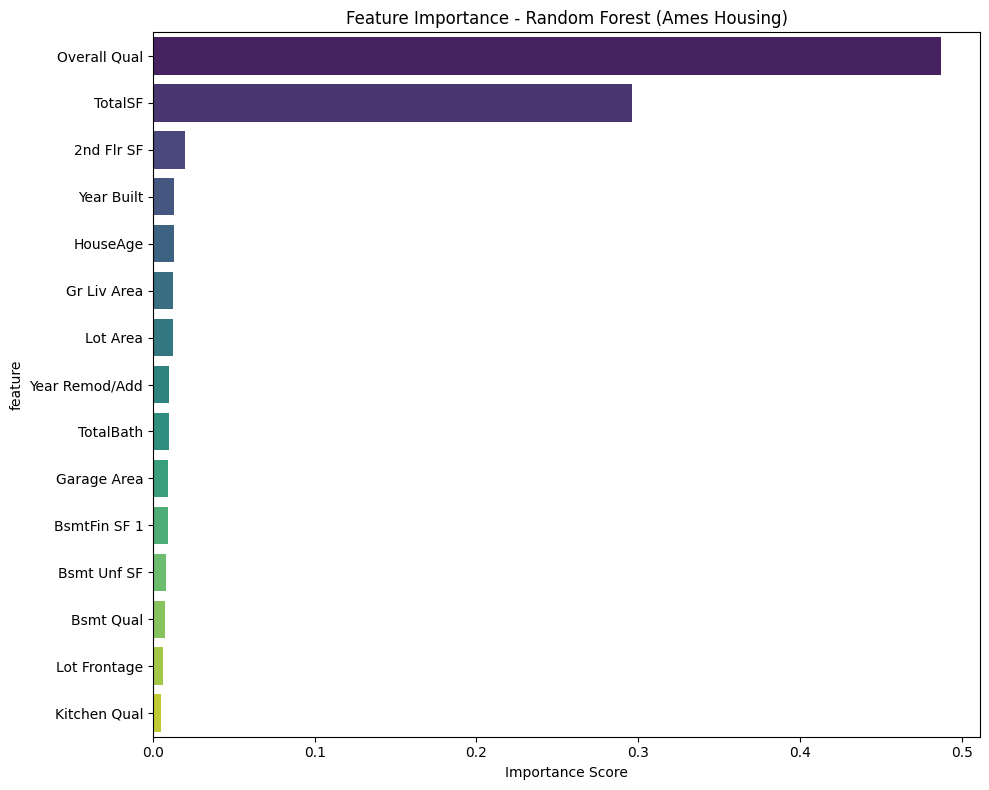

In [38]:
# Cell 28: Visualisasi feature importance dari model terbaik (Random Forest setelah tuning)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Tampilkan top 15 fitur
top_features = feature_importance.head(15)
print("Top 15 fitur paling berpengaruh:")
print(top_features)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Feature Importance - Random Forest (Ames Housing)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

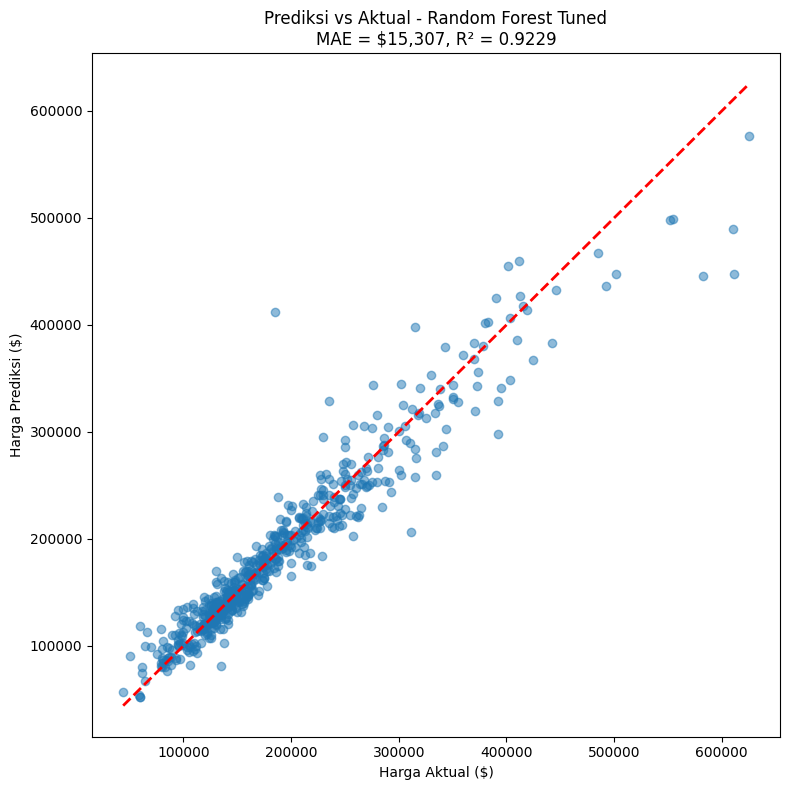

In [39]:
# Cell 29: Plot prediksi vs aktual untuk model terbaik
y_pred_test = best_rf.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Harga Aktual ($)')
plt.ylabel('Harga Prediksi ($)')
plt.title(f'Prediksi vs Aktual - Random Forest Tuned\nMAE = ${test_mae_tuned:,.0f}, R² = {test_r2_tuned:.4f}')
plt.tight_layout()
plt.show()

In [42]:
# Cell 30: Kesimpulan akhir
print("="*60)
print("KESIMPULAN PORTOFOLIO: AMES HOUSING PRICE PREDICTION")
print("="*60)

print("\n1. DATA PREPARATION")
print("   - Dataset: 2930 baris, 82 fitur awal")
print("   - Missing values: ditangani dengan median/modus dan drop kolom >40% missing")
print("   - Feature engineering: TotalSF, HouseAge, IsRemodeled, TotalBath")

print("\n2. MODEL EVALUATION")
print(f"   - Linear Regression R²: {results_df[results_df['model']=='Linear Regression']['test_r2'].values[0]:.4f}")
print(f"   - Ridge R²: {results_df[results_df['model']=='Ridge']['test_r2'].values[0]:.4f}")
print(f"   - Lasso R²: {results_df[results_df['model']=='Lasso']['test_r2'].values[0]:.4f}")
print(f"   - Random Forest R²: {results_df[results_df['model']=='Random Forest']['test_r2'].values[0]:.4f}")

print("\n3. BEST MODEL (after tuning)")
print(f"   - Model: Random Forest dengan hyperparameter terbaik")
print(f"   - Test MAE: ${test_mae_tuned:,.0f}")
print(f"   - Test R²: {test_r2_tuned:.4f}")
print(f"   - Artinya: model menjelaskan {test_r2_tuned*100:.1f}% variasi harga rumah")

print("\n4. TOP 5 FEATURES")
for i, row in top_features.head(5).iterrows():
    print(f"   - {row['feature']}: importance {row['importance']:.4f}")

print("\n5. BUSINESS INSIGHT")
print("   - Fitur terpenting: Overall Qual, TotalSF, Year Built, dll.")
print("   - Model dapat digunakan untuk estimasi harga rumah dengan error sekitar $20,000")
print("   - Rekomendasi: gunakan Random Forest untuk prediksi harga properti")



KESIMPULAN PORTOFOLIO: AMES HOUSING PRICE PREDICTION

1. DATA PREPARATION
   - Dataset: 2930 baris, 82 fitur awal
   - Missing values: ditangani dengan median/modus dan drop kolom >40% missing
   - Feature engineering: TotalSF, HouseAge, IsRemodeled, TotalBath

2. MODEL EVALUATION
   - Linear Regression R²: 0.8594
   - Ridge R²: 0.8594
   - Lasso R²: 0.8593
   - Random Forest R²: 0.9227

3. BEST MODEL (after tuning)
   - Model: Random Forest dengan hyperparameter terbaik
   - Test MAE: $15,307
   - Test R²: 0.9229
   - Artinya: model menjelaskan 92.3% variasi harga rumah

4. TOP 5 FEATURES
   - Overall Qual: importance 0.4870
   - TotalSF: importance 0.2960
   - 2nd Flr SF: importance 0.0200
   - Year Built: importance 0.0129
   - HouseAge: importance 0.0128

5. BUSINESS INSIGHT
   - Fitur terpenting: Overall Qual, TotalSF, Year Built, dll.
   - Model dapat digunakan untuk estimasi harga rumah dengan error sekitar $20,000
   - Rekomendasi: gunakan Random Forest untuk prediksi harga pro

In [46]:
# Cell 31 (Revisi): Simpan model, scaler, dan feature names
import joblib

joblib.dump(best_rf, 'best_ames_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'feature_names.pkl')
print("Model, scaler, dan feature names telah disimpan.")

Model, scaler, dan feature names telah disimpan.
